## 12.03 目标检测和边界框


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


---


### 练习 12.3.1

**题目：** 找到另一张图像，然后尝试标记包含该对象的边界框。比较标注边界框和标注类别哪个需要更长的时间？

**解答：**

&emsp;&emsp;标注边界框需要更长的时间：标注类别只需判断“是什么”，而标注边界框还需要精确定位“在哪”，需要为每个目标逐一调整框的四个角点坐标，工作量更大。下面以 `images/cat1.jpg`（猫的图片）为例，标记包含该对象的边界框。

以下使用 `torch` 编程进行验证：


image size: 400 x 500


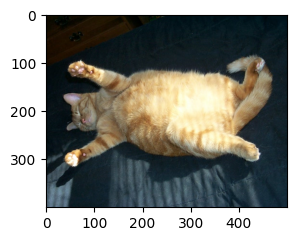

In [6]:
set_figsize()
img = plt.imread('../images/cat1.jpg')
h, w = img.shape[:2]
print(f'image size: {h} x {w}')
plt.imshow(img);

In [7]:
# 手工标记猫的边界框（左上x, 左上y, 右下x, 右下y）
cat_bbox = [30.0, 60.0, 370.0, 480.0]
boxes = torch.tensor((cat_bbox,))
# 两种表示法之间往返转换，验证坐标正确性
box_center_to_corner(box_corner_to_center(boxes)) == boxes

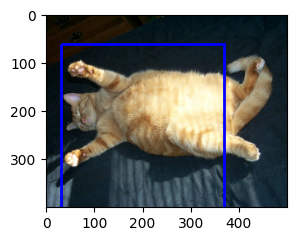

In [8]:
fig = plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(cat_bbox, 'blue'));

&emsp;&emsp;可以看到，猫的主要轮廓基本落在标记的边界框内。相比之下，标注“猫”这个类别只需一眼即可完成，而边界框需要反复对比框与物体轮廓是否贴合，因此耗时更长。

使用 `PyPTO` 编程进行验证（边界框坐标转换走 NPU kernel）：


往返转换一致: True
中心/宽高表示: tensor([[200., 270., 340., 420.]], device='npu:1')


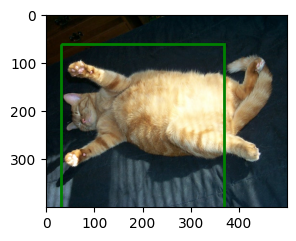

In [10]:
from src.PyPTOAnchor import box_corner_to_center, box_center_to_corner

boxes = torch.tensor((cat_bbox,), device=device)
# 从（左上，右下）转换到（中心，宽，高），再转回
cc = box_corner_to_center(boxes)
back = box_center_to_corner(cc)
print('往返转换一致:', torch.allclose(back, boxes))
print('中心/宽高表示:', cc)

# 用 PyPTO 往返后的坐标在原图上画边界框（与 torch 版同图对比）
fig = plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(back.cpu()[0].tolist(), 'green'));

---


### 练习 12.3.2

**题目：** 为什么`box_corner_to_center`和`box_center_to_corner`的输入参数的最内层维度总是4？

**解答：**

&emsp;&emsp;`box_corner_to_center`和`box_center_to_corner`是在目标检测中广泛使用的边界框坐标转换函数。输入参数的最内层维度总是4，原因在于边界框通常基于矩形框的四个坐标或尺寸信息来定义：

- 对于`box_corner_to_center`，输入的边界框表示形式基于四个角点坐标：`[左上x, 左上y, 右下x, 右下y]`；
- 对于`box_center_to_corner`，输入的边界框表示形式基于中心点坐标以及边界框的宽和高：`[中心x, 中心y, 宽度, 高度]`。

&emsp;&emsp;无论批量中有多少个边界框（第0维为$n$），每个边界框都只需要这4个标量即可完整描述，因此最内层维度恒为4。

以下使用 `torch` 编程进行验证：


In [13]:
# 最内层维度始终为 4：单个边界框 (1,4)、多个边界框 (n, 4)
from src.D2LFunction import box_corner_to_center, box_center_to_corner  # torch 版本
for shp in [(1, 4), (2, 4), (3, 4)]:
    b = torch.rand(*shp)
    print(shp, '->', box_center_to_corner(box_corner_to_center(b)).shape)

(1, 4) -> torch.Size([1, 4])
(2, 4) -> torch.Size([2, 4])
(3, 4) -> torch.Size([3, 4])


使用 `PyPTO` 编程进行验证（`src/PyPTOAnchor.py` 中 kernel 同样要求末维为4，host 端会 pad 到 8 以满足 32 字节对齐）：


In [15]:
X = torch.rand(5, 4, device=device)
print('输入最内层维度:', X.shape[-1])
Y = box_corner_to_center(X)
print('输出形状:', Y.shape)  # 仍为 (5, 4)，最内层是 [cx, cy, w, h]

输入最内层维度: 4
输出形状: torch.Size([5, 4])


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
